In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

output_file         = '../05_output/'
osap_data           = '../03_data/osap/'

temp_dir = "D:/github_repositories"
os.environ["TEMP"] = temp_dir
os.environ["TMP"] = temp_dir
os.environ["JOBLIB_TEMP_FOLDER"] = temp_dir

In [2]:
signalnames     = np.load(osap_data + 'signalnames.npy', allow_pickle=True)
date            = np.load(osap_data + 'date.npy')
ret             = np.load(osap_data + 'ret.npy')
signals         = np.load(osap_data + 'signals.npy')

In [3]:
def equal_weight(ret, signals):
    N, T            = ret.shape
    valid           = ~np.isnan(ret) & ~np.any(np.isnan(signals), axis=2)
    Nt              = np.sum(valid, axis=0, keepdims=True)
    Nt_mat          = np.tile(Nt, (N, 1))
    weight          = np.where(valid, 1/Nt_mat, np.nan)
    return weight

def value_weight(ret, size):
    me      = size[:, :] 
    valid   = ~np.isnan(ret) & ~np.isnan(me)
    me      = np.where(valid, me, 0)
    totme   = np.sum(me, axis=0, keepdims=True)
    weight  = np.where(valid, me/totme, np.nan)
    return weight

def ppp_port(ret, signals, delta, gamma, p):
    def utilityf(rp, gamma):
        if gamma == 1:
            return cp.log(1+rp)
        else:
            return cp.power(1+rp, 1-gamma)/(1-gamma)
    
    N, T, L     = signals.shape
    valid       = ~np.isnan(ret) & ~np.any(np.isnan(signals), axis=2)
    Nt          = np.sum(valid, axis=0, keepdims=True)
    Nt_mat      = np.tile(Nt, (N, 1))

    signals       = np.where(valid[:, :, np.newaxis], signals, 0.0)
    ret        = np.where(valid, ret, 0.0)

    theta       = cp.Variable((L, 1))
    w           = cp.multiply(cp.squeeze(signals.transpose((1, 0, 2)) @ theta, axis=2), 1/Nt_mat.T) + valid.T/Nt_mat.T
    rp          = cp.sum(cp.multiply(w, ret.transpose(1, 0)), axis=1)
    u           = utilityf(rp, gamma)

    objective   = cp.Minimize(- cp.mean(u) + delta*cp.norm(theta, p))
    # constraints = [w >= 0]
    prob        = cp.Problem(objective)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    return theta.value.reshape(-1, 1)

In [ ]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

def _single_step(i, ret, signals, size, train_len, port_num, strategy_num, use_chars, p):
    rng = np.random.default_rng(45 + i)
    train_xret  = ret[:, :i+train_len] # xret_cut[:, :-1]
    train_chars = signals[:, :i+train_len, :] # chars_cut[:, :-1, :]
    train_chars = (train_chars - np.nanmean(train_chars, axis=0, keepdims=True))/np.nanstd(train_chars, axis=0, keepdims=True)

    test_xret   = ret[:, i+train_len:i+train_len+1] # xret_cut[:, -1:]
    test_chars  = signals[:, i+train_len:i+train_len+1, :] # chars_cut[:, -1:, :]
    test_size   = size[:, i+train_len:i+train_len+1] # size_cut[:, -1:]
    valid       = (~np.isnan(test_xret) & ~np.any(np.isnan(test_chars), axis=2))
    if np.sum(valid) > port_num and port_num != -1:
        valid_idx           = np.where(valid.flatten())[0]
        idx                 = rng.permutation(valid_idx)[:port_num]
        new_valid           = np.zeros_like(valid)
        new_valid[idx, :]   = 1
    else:
        new_valid           = valid

    test_xret   = np.where(new_valid, test_xret, np.nan)
    test_chars  = np.where(np.tile(new_valid[:, :, np.newaxis], (1, 1, signals.shape[2])), test_chars, np.nan)
    test_chars  = (test_chars - np.nanmean(test_chars, axis=0, keepdims=True))/np.nanstd(test_chars, axis=0, keepdims=True)

    wlist = []

    # equal weight
    weight_e    = equal_weight(test_xret, test_chars)

    # value weight
    weight_v    = value_weight(test_xret, test_size)

    # ppp weight
    theta       = ppp_port(train_xret, train_chars, delta=0, gamma=5, p=2)
    weight_ppp  = np.squeeze(test_chars @ theta, axis=2)*weight_e + weight_e

    weight_e    = np.where(new_valid, weight_e, 0)
    weight_v    = np.where(new_valid, weight_v, 0)
    weight_ppp  = np.where(new_valid, weight_ppp, 0)

    wlist.append(np.squeeze(weight_e, axis=1))
    wlist.append(np.squeeze(weight_v, axis=1))
    wlist.append(np.squeeze(weight_ppp, axis=1))
    
    test_xret   = np.where(new_valid, test_xret, 0)
    port_ret = np.full((strategy_num,), np.nan)
    for j, weight in enumerate(wlist):
        weight  = np.where(~np.isnan(weight), weight, 0)
        port_ret[j] = weight @ test_xret[:, :]
    
    return i, port_ret

def evaluate(ret, signals, size, train_len, port_num, strategy_num, use_chars=0, p=2, s=0, n_jobs=1):
    N, T, L     = signals.shape
    T_steps     = T-train_len-1
    port_ret    = np.full((strategy_num, T_steps), np.nan)
    size        = signals[:, :, 1]
    with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
        results = dict(parallel(
            delayed(_single_step)(i, ret, signals, size, train_len, port_num, strategy_num, use_chars, p) for i in tqdm(range(T_steps))
        ))
    for k, v in results.items():
        port_ret[:, k] = v

    return port_ret

# 100 stocks

In [ ]:
charslist       = np.where(np.isin(signalnames, ['BM', 'Size', 'Mom12m']))[0]
sizelist        = np.where(np.isin(signalnames, ['Size']))[0]
port_ret        = evaluate(
                    ret[:, :], 
                    signals[:, :, charslist], 
                    signals[:, :, sizelist], 
                    train_len=120, 
                    port_num=-1, 
                    strategy_num=3, 
                    use_chars=0, 
                    p=2, s=0, n_jobs=8
                )
results         = pd.DataFrame({
                    'mean':         np.round(np.mean(port_ret, axis=1)*12, 4), 
                    'std':          np.round(np.std(port_ret, axis=1)*np.sqrt(12), 4),
                    'sharpe ratio': np.round(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)), 4),
                }, index=['equal weited', 'value weighted', 'ppp'])
results

100%|██████████| 478/478 [08:12<00:00,  1.03s/it]


,mean,std,sharpe ratio
equal weited,0.1124,0.2114,0.5316
value weighted,0.1069,0.2065,0.5178
ppp,0.3774,0.6796,0.5553


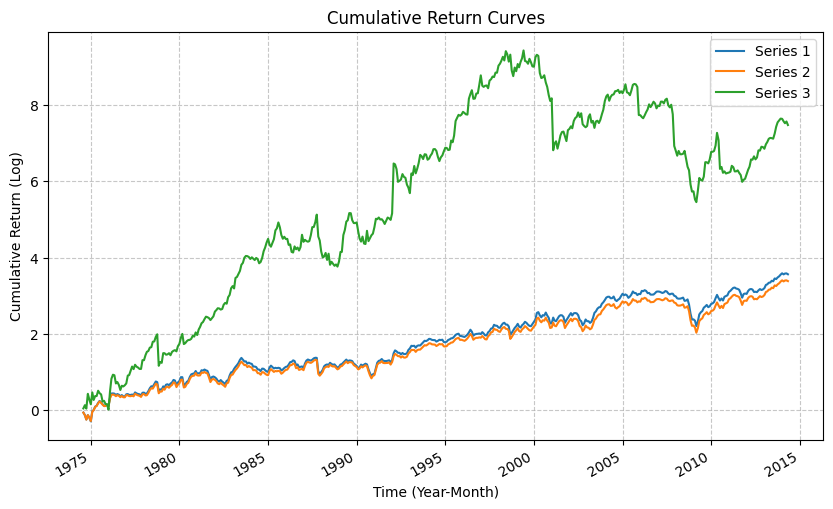

In [15]:
def plot_cumulative_returns(x_axis, *return_series):
    plt.figure(figsize=(10, 6))
    x_date = pd.to_datetime(x_axis, format='%Y%m', errors='coerce')
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        cumulative = np.cumsum(np.log(1 + series))
        
        plt.plot(x_date, cumulative, label=f"Series {i}")
    
    # 自动调整日期标签的倾斜度，防止重叠
    plt.gcf().autofmt_xdate()
    
    plt.xlabel("Time (Year-Month)")
    plt.ylabel("Cumulative Return (Log)")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_cumulative_returns(date[121:], port_ret[0], port_ret[1], port_ret[2])

# all stocks

In [ ]:
charslist = np.where(np.isin(signalnames, ['beme', 'lme', 'cum_return_12_2']))[0]
port_ret = evaluate(ret[:, :], signals[:, :, charslist], train_len=120, port_num=-1, strategy_num=3, use_chars=0, p=2, s=0, n_jobs=8)
results = pd.DataFrame({
    'mean':         np.round(np.mean(port_ret, axis=1), 4), 
    'std':          np.round(np.std(port_ret, axis=1), 4),
    'sharpe ratio': np.round(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)), 4),
}, index=['equal weited', 'value weighted', 'ppp'])
results

,mean,std,sharpe ratio
equal weited,0.0108,0.0591,0.6320
value weighted,0.0101,0.0579,0.6035
ppp,0.0263,0.0898,1.0166


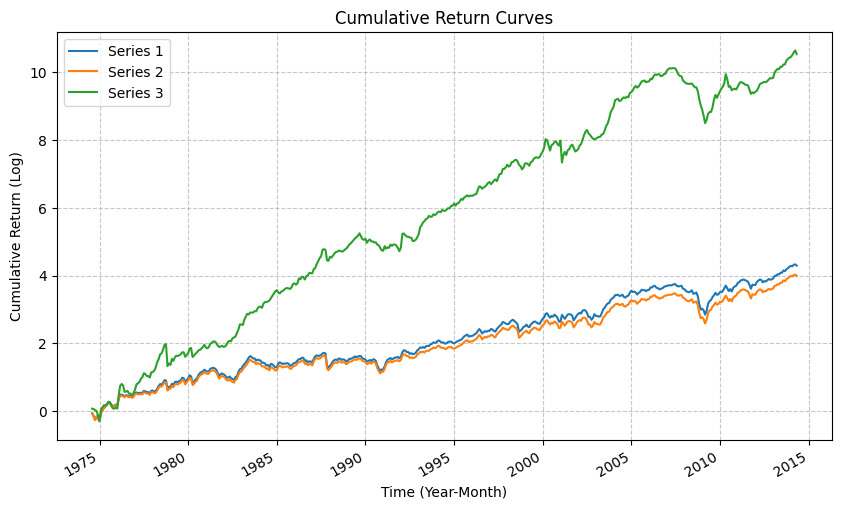

In [17]:
def plot_cumulative_returns(x_axis, *return_series):
    plt.figure(figsize=(10, 6))
    x_date = pd.to_datetime(x_axis, format='%Y%m', errors='coerce')
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        cumulative = np.cumsum(np.log(1 + series))
        
        plt.plot(x_date, cumulative, label=f"Series {i}")
    
    # 自动调整日期标签的倾斜度，防止重叠
    plt.gcf().autofmt_xdate()
    
    plt.xlabel("Time (Year-Month)")
    plt.ylabel("Cumulative Return (Log)")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_cumulative_returns(date[121:], port_ret[0], port_ret[1], port_ret[2])